# 02 Sequential credit and scaling

Every displayed result is computed from the scientific implementation in this repository. The reduced default uses fewer seeds/episodes and parallel independent cells; `publication` restores the original budgets. Numerical archives are an explicit opt-in and are never required for the live default. Figures display inline once and saving is disabled unless requested.

## Configuration

In [1]:
from pathlib import Path
import hashlib, json, os, sys

# One BLAS thread per process: independent scientific cells are parallelised instead.
for _name in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_name, "1")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

RUN_PROFILE = os.getenv("MRL_RUN_PROFILE", "reduced")  # smoke | reduced | publication
DEVICE = os.getenv("MRL_DEVICE", "auto")
WORKERS = os.getenv("MRL_WORKERS", "auto")
SAVE_FIGURES = os.getenv("MRL_SAVE_FIGURES", "0") == "1"
OUTPUT_DIR = Path(os.getenv("MRL_OUTPUT_DIR", "generated_figures"))
OVERWRITE = os.getenv("MRL_OVERWRITE", "0") == "1"
RUN_EXTERNAL_DATA = os.getenv("MRL_RUN_EXTERNAL_DATA", "0") == "1"
ALLOW_DATA_DOWNLOADS = os.getenv("MRL_ALLOW_DATA_DOWNLOADS", "0") == "1"
USE_ARCHIVED_RESULTS = os.getenv("MRL_USE_ARCHIVED_RESULTS", os.getenv("MRL_USE_NUMERICAL_ARCHIVES", "0")) == "1"

if RUN_PROFILE not in {"smoke", "reduced", "publication"}:
    raise ValueError(f"unknown RUN_PROFILE={RUN_PROFILE!r}")

HERE = Path.cwd()
ROOT = HERE.parent if HERE.name == "experiments" else HERE
sys.path.insert(0, str(ROOT / "src"))
RESULTS = ROOT / "data" / "results"
OWNED = ("fig_dmax_dense.png", "fig_sequential.png", "fig_scaling.png", "fig_hybrid.png")
FIGURE_REPORT = []

cpu = os.cpu_count() or 4
RESOLVED_WORKERS = max(1, min(8, cpu - 2)) if WORKERS == "auto" else max(1, int(WORKERS))

try:
    import torch
    TORCH_AVAILABLE = True
    if DEVICE == "cpu":
        SELECTED_DEVICE = "cpu"
    elif torch.cuda.is_available():
        SELECTED_DEVICE = "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        SELECTED_DEVICE = "mps"
    else:
        SELECTED_DEVICE = "cpu"
except (ImportError, OSError):
    TORCH_AVAILABLE = False
    SELECTED_DEVICE = "unavailable"

print({"profile": RUN_PROFILE, "requested_device": DEVICE, "selected_device": SELECTED_DEVICE,
       "workers": RESOLVED_WORKERS, "saving": SAVE_FIGURES,
       "numerical_archives": USE_ARCHIVED_RESULTS, "python": sys.executable})

{'profile': 'reduced', 'requested_device': 'auto', 'selected_device': 'unavailable', 'workers': 4, 'saving': False, 'numerical_archives': False, 'python': 'C:\\Users\\User\\anaconda3\\python.exe'}


## Inline display, optional saving, and provenance

In [2]:
def _normalise(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(k): _normalise(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_normalise(v) for v in value]
    return value

def data_hash(value):
    blob = json.dumps(_normalise(value), sort_keys=True, separators=(",", ":"), default=str)
    return hashlib.sha256(blob.encode()).hexdigest()

def load_archive(name):
    path = RESULTS / name
    if not (USE_ARCHIVED_RESULTS and path.exists()):
        return None
    value = np.load(path, allow_pickle=True).item()
    print(f"using optional numerical archive: {path.name}")
    return value

def _safe_save(fig, filename):
    if not SAVE_FIGURES:
        return None
    out = OUTPUT_DIR.expanduser().resolve()
    if "manuscript" in str(out).lower() and not OVERWRITE:
        raise FileExistsError("writing into a manuscript directory requires OVERWRITE=True")
    out.mkdir(parents=True, exist_ok=True)
    path = out / filename
    if path.exists() and not OVERWRITE:
        raise FileExistsError(path)
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    return str(path)

def finish(fig, filename, source, meta):
    if filename not in OWNED:
        raise KeyError(f"unregistered notebook figure: {filename}")
    saved = _safe_save(fig, filename)
    provenance = meta.get("method_provenance") if isinstance(meta, dict) else None
    if provenance is None:
        provenance = {"status": "adapted", "established_basis": [],
                      "repository_adaptation": "repository-owned experiment",
                      "claim_limit": "descriptive within the stated model and task"}
    record = dict(filename=filename,
                  provenance_class=("published-aggregate" if source.startswith("numerical-archive") else source),
                  claim_status=("aggregate-reproduction" if source.startswith("numerical-archive") else
                                "exact-reproduction" if source == "live-exact" else "reduced-validation"),
                  runtime_profile=RUN_PROFILE, runtime_device=LIVE_DEVICE,
                  runtime_workers=RESOLVED_WORKERS, runtime_source=source,
                  runtime_meta=_normalise(meta), method_provenance=_normalise(provenance),
                  data_hash=data_hash(meta), saved_path=saved,
                  display_status="generated live" if source.startswith("live") else source)
    FIGURE_REPORT.append(record)
    display(fig)
    plt.close(fig)
    return record

## Simulated retention–delay design curve

This is an internally generated simulation sensitivity: retention directly sets trace decay, so the curve is not an independently validated physical law. The reduced profile concentrates live samples around criterion crossings; publication mode uses the predefined absolute-delay grid. Historical `D_max` archives are deliberately not loaded because they lack the corrected task and provenance schema.

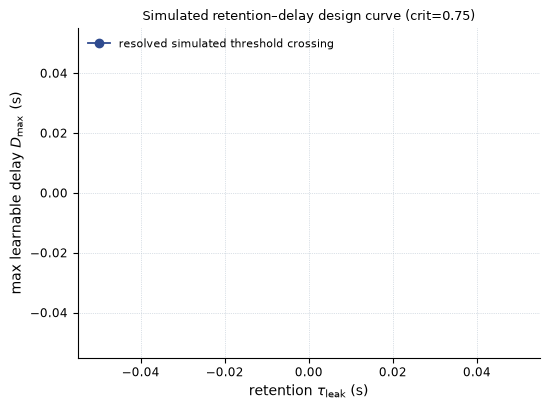

In [3]:
from mrl_trace.maze import run_retention_delay_curve, run_retention_delay_curve_adaptive
from mrl_trace.model_specs import PRIMARY_MODEL_ID, device_model_spec
MODEL_SPECIFICATION = device_model_spec(PRIMARY_MODEL_ID)

if RUN_PROFILE == "smoke":
    dmax_result = run_retention_delay_curve_adaptive(
        seeds=1, episodes=40, taus=(1, 5, 20, 40), delay_ratios=(8, 16),
        workers=min(2, RESOLVED_WORKERS))
elif RUN_PROFILE == "reduced":
    dmax_result = run_retention_delay_curve_adaptive(
        seeds=3, episodes=220, workers=RESOLVED_WORKERS)
else:
    dmax_result = run_retention_delay_curve(
        seeds=20, episodes=800, workers=RESOLVED_WORKERS)
LIVE_SOURCE = "live-exact" if RUN_PROFILE == "publication" else "live-reduced"

taus = np.asarray(dmax_result["taus"], float)
dvals = np.asarray([dmax_result["dmax"][t] for t in dmax_result["taus"]], float)
censored = np.asarray(dmax_result["censored"], bool)
fitmask = (~censored) & (dvals > 0)
crit = dmax_result["crit"]
resolved_tau = taus[fitmask]
resolved_delay = dvals[fitmask]
local_slopes = np.diff(resolved_delay) / np.diff(resolved_tau) if len(resolved_tau) > 1 else np.array([])
curvature = np.diff(local_slopes) if len(local_slopes) > 1 else np.array([])
LIVE_DEVICE = "cpu"
LIVE_META = dict(dmax_result, local_slopes=local_slopes, curvature=curvature,
                 interpretation="simulation sensitivity; not an independent physical law")

INK = "#2b2b2b"; BRICK = "#c0392b"; INDIGO = "#2f4b8f"; TEAL = "#3aa07a"; GRID = "#b8c4d0"
def _figure(taus, dvals, censored, fitmask, crit):
    fig, ax = plt.subplots(figsize=(5.6, 4.2))
    ax.plot(taus[fitmask], dvals[fitmask], "o-", color=INDIGO, lw=1.3, ms=6,
            zorder=4, label="resolved simulated threshold crossing")
    if censored.any():
        ax.scatter(taus[censored], dvals[censored], s=58, marker="^", color="#e0a93b",
                   edgecolor="white", zorder=4,
                   label="censored ($D_{\\max}\\geq$ grid max)")
    ax.set_xlabel(r"retention $\tau_{\rm leak}$ (s)", fontsize=10)
    ax.set_ylabel(r"max learnable delay $D_{\max}$ (s)", fontsize=10)
    ax.grid(True, ls=":", lw=0.5, color=GRID); ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8.5)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_title(f"Simulated retention–delay design curve (crit={crit})",
                 fontsize=9.5)
    fig.tight_layout()
    finish(fig, "fig_dmax_dense.png", LIVE_SOURCE, LIVE_META)



_figure(taus, dvals, censored, fitmask, crit)

## Controlled multi-decision action sequence

The cue-conditioned sequence task requires four consequential actions `(0, 1, 1, 0)` before terminal reward; a wrong action terminates unrewarded and a constant policy cannot solve it. Comparator update scales are calibrated on 256 fixed balanced trajectories, learning rates are selected by unsmoothed AULC on seeds 1000–1019, and evaluation uses untouched seeds 2000–2019. The primary operating point is the explicitly synthetic 10 s retention, 12 s delay, 1.5 V, k=3, beta=1 configuration. The matched exponential retains the custom signed drive, the linear-device condition is the Erlang sensitivity, and conventional R-STDP is the distinct pair-based comparator. The shallow e-prop-style policy trace is a repository-specific feed-forward adaptation, not the complete recurrent e-prop algorithm. Historical one-choice results are not loaded.

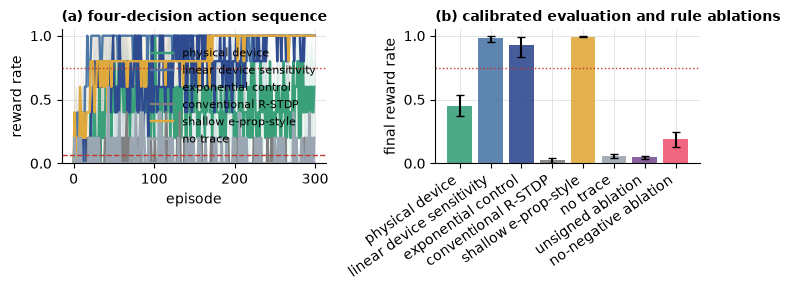

In [4]:
from mrl_trace.maze import run_action_sequence
from mrl_trace.stats import bootstrap_ci

if RUN_PROFILE == "smoke":
    eval_seeds, tune_seeds = range(2000, 2002), range(1000, 1002)
    seq_result = run_action_sequence(
        episodes=80, tuning_episodes=40, calibration_trajectories=256,
        tuning_seeds=tune_seeds, evaluation_seeds=eval_seeds, workers=RESOLVED_WORKERS)
elif RUN_PROFILE == "reduced":
    eval_seeds, tune_seeds = range(2000, 2005), range(1000, 1005)
    seq_result = run_action_sequence(
        episodes=300, tuning_episodes=150, calibration_trajectories=256,
        tuning_seeds=tune_seeds, evaluation_seeds=eval_seeds, workers=RESOLVED_WORKERS)
else:
    seq_result = run_action_sequence(episodes=300, tuning_episodes=300, workers=RESOLVED_WORKERS)
LIVE_SOURCE = "live-exact" if RUN_PROFILE == "publication" else "live-reduced"

curves = {key: np.asarray(value, float) for key, value in seq_result["curves"].items()}
finals = {key: np.asarray(value, float) for key, value in seq_result["finals"].items()}
chance, crit = 0.5 ** len(seq_result["required_actions"]), 0.75
LIVE_DEVICE = "cpu"
LIVE_META = seq_result
DEVC = "#3aa07a"; EXP = "#2f4b8f"; NTC = "#9aa6b2"; CR = "#c0392b"
ORDER = ("device", "linear_device", "exponential", "conventional_rstdp", "shallow_eprop", "no_trace",
         "device_unsigned", "device_no_negative")
LABEL = {"device": "physical device", "linear_device": "linear device sensitivity", "exponential": "exponential control",
         "conventional_rstdp": "conventional R-STDP",
         "shallow_eprop": "shallow e-prop-style", "no_trace": "no trace",
         "device_unsigned": "unsigned ablation",
         "device_no_negative": "no-negative ablation"}
COLOUR = {"device": DEVC, "linear_device": "#4c78a8", "exponential": EXP, "conventional_rstdp": "#7f7f7f",
          "shallow_eprop": "#e0a93b",
          "no_trace": NTC, "device_unsigned": "#7a5195",
          "device_no_negative": "#ef5675"}
def _bootstrap_curve_ci(values, n_boot=10000, seed=0, chunk=250):
    """Percentile bootstrap over evaluation seeds at every episode."""
    values = np.asarray(values, float)
    if len(values) == 1:
        return values[0].copy(), values[0].copy()
    rng = np.random.default_rng(seed)
    boot = np.empty((n_boot, values.shape[1]), dtype=np.float32)
    for start in range(0, n_boot, chunk):
        stop = min(n_boot, start + chunk)
        indices = rng.integers(0, len(values), size=(stop - start, len(values)))
        boot[start:stop] = values[indices].mean(axis=1)
    low, high = np.percentile(boot, (2.5, 97.5), axis=0)
    return low, high


def _figure(curves, finals, chance, crit):
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.2, 3.0))
    for name in ("device", "linear_device", "exponential", "conventional_rstdp", "shallow_eprop", "no_trace"):
        values = curves[name]
        mean = values.mean(axis=0)
        low, high = _bootstrap_curve_ci(values, seed=3000 + ORDER.index(name))
        tt = np.arange(len(mean))
        axA.plot(tt, mean, color=COLOUR[name], lw=1.7, label=LABEL[name])
        axA.fill_between(tt, low, high,
                         color=COLOUR[name], alpha=0.12, lw=0)
    axA.axhline(chance, ls="--", color=CR, lw=1.0)
    axA.axhline(crit, ls=":", color=CR, lw=1.0)
    axA.set_xlabel("episode"); axA.set_ylabel("reward rate")
    axA.set_ylim(0, 1.05); axA.set_title("(a) four-decision action sequence", loc="left",
                                           fontsize=10, fontweight="bold")
    axA.grid(True, which="major", color="0.85", lw=0.5, zorder=0); axA.set_axisbelow(True)
    axA.legend(frameon=False, fontsize=8); axA.spines[["top", "right"]].set_visible(False)

    names = [name for name in ORDER if name in finals]
    means = np.asarray([finals[name].mean() for name in names])
    intervals = [bootstrap_ci(finals[name], seed=4000 + index)
                 for index, name in enumerate(names)]
    errors = np.vstack((means - np.asarray([ci[0] for ci in intervals]),
                        np.asarray([ci[1] for ci in intervals]) - means))
    x = np.arange(len(names))
    axB.bar(x, means, yerr=errors, color=[COLOUR[name] for name in names],
            alpha=0.9, capsize=3)
    axB.axhline(crit, ls=":", color=CR, lw=1.0, label="criterion")
    axB.set_xticks(x); axB.set_xticklabels([LABEL[name] for name in names], rotation=35, ha="right")
    axB.set_ylabel("final reward rate"); axB.set_ylim(0, 1.05)
    axB.set_title("(b) calibrated evaluation and rule ablations", loc="left",
                  fontsize=10, fontweight="bold")
    axB.grid(True, which="major", color="0.85", lw=0.5, zorder=0)
    axB.set_axisbelow(True)
    axB.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    finish(fig, "fig_sequential.png", LIVE_SOURCE, LIVE_META)



_figure(curves, finals, chance, crit)

## Closed-loop scaling and remedies

The reduced run retains all six array sizes and all five interventions, using a shorter trial budget. The two panels use the authored source generator verbatim; only their live result objects replace the original `.npy` loads.

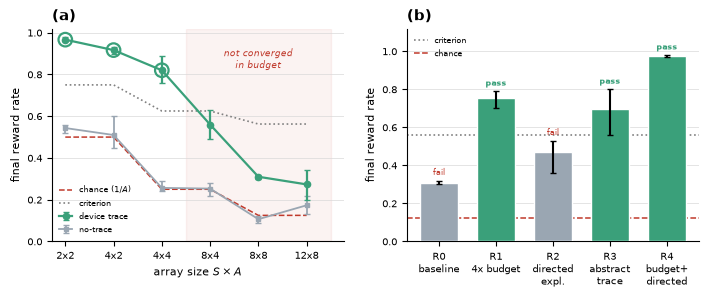

{'filename': 'fig_scaling.png',
 'provenance_class': 'live-reduced',
 'claim_status': 'reduced-validation',
 'runtime_profile': 'reduced',
 'runtime_device': 'cpu',
 'runtime_workers': 4,
 'runtime_source': 'live-reduced',
 'runtime_meta': {'scaling': {'(2, 2)': {'chance': 0.5,
    'crit': 0.75,
    'device': [0.9666666666666667, 0.009428090415820642, 0.96, 0.98],
    'no_trace': [0.5433333333333333, 0.016996731711975962, 0.52, 0.56],
    'trials_to_crit': 274,
    'n_converged': 3,
    'passed': True,
    'n_seeds': 3,
    'trials': 1500,
    'retention_definition': 'deliberately_swept',
    'method_provenance': {'status': 'proposed',
     'established_basis': ['contextual bandit evaluation',
      'leaky integrate-and-fire dynamics',
      'three-factor reward modulation'],
     'repository_adaptation': "The repository's signed coincidence drive is integrated by either the cascade eligibility surrogate or an explicit exponential control.",
     'claim_limit': 'Results test this repos

In [5]:
from mrl_trace.bandit import run_remedies, run_scaling

r4 = load_archive("tier4_results.npy")
r5 = load_archive("tier5_results.npy")
if r4 is None or r5 is None:
    if RUN_PROFILE == "smoke":
        seeds, trials, mult, workers = 1, 30, 2, min(2, RESOLVED_WORKERS)
    elif RUN_PROFILE == "reduced":
        # Keep a small seed batch, but preserve the authored 1500-trial convergence
        # budget: shortening this axis changes the scaling/remedy claim, not just its CI.
        seeds, trials, mult, workers = 3, 1500, 4, RESOLVED_WORKERS
    else:
        seeds, trials, mult, workers = 20, 1500, 4, RESOLVED_WORKERS
    r4 = run_scaling(seeds=seeds, trials=trials, workers=workers)
    r5 = run_remedies(seeds=seeds, trials=trials, budget_multiplier=mult, workers=workers)
    LIVE_SOURCE = "live-exact" if RUN_PROFILE == "publication" else "live-reduced"
else:
    LIVE_SOURCE = "numerical-archive"
LIVE_DEVICE = "cpu"
LIVE_META = {"scaling": r4, "remedies": r5}
DEVC = "#3aa07a"; NTC = "#9aa6b2"; CR = "#c0392b"; CH = "#2b2b2b"; OKC = "#3aa07a"

fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.0, 2.9))

# ---------------- Panel (a): scaling ----------------
cells = [(2, 2), (4, 2), (4, 4), (8, 4), (8, 8), (12, 8)]
labels = [f"{S}x{A}" for S, A in cells]
# result tuples are (mean, sd, lo, hi); error bars are the bootstrap 95% CI
def _ci_err(entries):
    m = np.array([e[0] for e in entries])
    lo = np.array([e[2] for e in entries])
    hi = np.array([e[3] for e in entries])
    return m, np.vstack([m - lo, hi - m])

dev, dev_err = _ci_err([r4[c]["device"] for c in cells])
nt, nt_err = _ci_err([r4[c]["no_trace"] for c in cells])
chance = np.array([r4[c]["chance"] for c in cells])
crit = np.array([r4[c]["crit"] for c in cells])
passed = np.array([r4[c]["passed"] for c in cells])
x = np.arange(len(cells))

axA.plot(x, chance, "--", color=CR, lw=1.1, label="chance ($1/A$)", zorder=2)
axA.plot(x, crit, ":", color="0.5", lw=1.2, label="criterion", zorder=2)
axA.errorbar(x, dev, yerr=dev_err, marker="o", ms=4.5, lw=1.6, color=DEVC,
             capsize=2.2, label="device trace", zorder=5)
axA.errorbar(x, nt, yerr=nt_err, marker="s", ms=3.5, lw=1.3, color=NTC,
             capsize=2.2, label="no-trace", zorder=4)
for xi, d, ok in zip(x, dev, passed):
    if ok:
        axA.scatter([xi], [d], s=95, facecolors="none", edgecolors=OKC, lw=1.6, zorder=6)
firstfail = int(np.argmax(~passed)) if np.any(~passed) else len(cells)
if firstfail < len(cells):
    axA.axvspan(firstfail - 0.5, len(cells) - 0.5, color=CR, alpha=0.06, zorder=0)
    # annotate near the top of the shaded band, where all traces have fallen away,
    # so the label sits in clear space rather than under the plotted lines
    axA.text((firstfail + len(cells) - 1) / 2, 0.93, "not converged\nin budget",
             fontsize=6.3, ha="center", va="top", color=CR, style="italic")
axA.set_xticks(x); axA.set_xticklabels(labels, fontsize=6.8, rotation=0)
axA.set_xlabel(r"array size $S\times A$", fontsize=8.2)
axA.set_ylabel("final reward rate", fontsize=8.2)
axA.set_ylim(0, 1.02); axA.tick_params(labelsize=7.2)
axA.legend(fontsize=5.9, frameon=False, loc="lower left", handlelength=1.6)
axA.spines[["top", "right"]].set_visible(False)
axA.grid(True, axis="y", color="0.85", lw=0.5, zorder=0)
axA.set_axisbelow(True)
axA.set_title("(a)", fontsize=10.5, fontweight="bold", loc="left")

# ---------------- Panel (b): remedies on 8x8 ----------------
keys = list(r5.keys())                          # preserves R0..R4 insertion order
short = ["R0\nbaseline", "R1\n4x budget", "R2\ndirected\nexpl.",
         "R3\nabstract\ntrace", "R4\nbudget+\ndirected"]
vals = np.array([r5[k]["final"][0] for k in keys])
# bootstrap 95% CI as asymmetric error bars
lo = np.array([r5[k]["final"][2] for k in keys])
hi = np.array([r5[k]["final"][3] for k in keys])
err = np.vstack([vals - lo, hi - vals])
psd = np.array([r5[k]["passed"] for k in keys])
# colour: passing rows teal/green, failing rows grey
bar_c = [DEVC if ok else NTC for ok in psd]
xb = np.arange(len(keys))
crit88 = 0.5 * (1 + 1.0 / 8)
axB.bar(xb, vals, yerr=err, color=bar_c, capsize=2.5, width=0.66,
        edgecolor="white", zorder=3)
axB.axhline(crit88, ls=":", color="0.5", lw=1.2, zorder=2, label="criterion")
axB.axhline(1.0 / 8, ls="--", color=CR, lw=1.1, zorder=2, label="chance")
for xi, v, h, ok in zip(xb, vals, hi, psd):
    # sit the verdict clear above the upper CI cap
    axB.text(xi, h + 0.03, "pass" if ok else "fail", fontsize=6.0, ha="center",
             color=(OKC if ok else CR), fontweight=("bold" if ok else "normal"))
axB.set_xticks(xb); axB.set_xticklabels(short, fontsize=6.0)
axB.set_ylabel("final reward rate", fontsize=8.2)
axB.set_ylim(0, 1.12); axB.tick_params(labelsize=7.2)
axB.legend(fontsize=6.0, frameon=False, loc="upper left", handlelength=1.6)
axB.spines[["top", "right"]].set_visible(False)
axB.grid(True, axis="y", color="0.85", lw=0.5, zorder=0)
axB.set_axisbelow(True)
axB.set_title("(b)", fontsize=10.5, fontweight="bold", loc="left")

fig.tight_layout(pad=0.4, w_pad=1.5)
finish(fig, "fig_scaling.png", LIVE_SOURCE, LIVE_META)

## Hybrid perception–decision stack

The schematic remains authored code, while panel (b) is generated from a freshly trained convolutional SNN and live three-factor decision runs. CUDA is selected automatically when the active environment provides it; the three decision conditions run in parallel CPU processes.

In [6]:
if not TORCH_AVAILABLE:
    if RUN_PROFILE == "publication":
        raise RuntimeError("publication hybrid figure requires a working torch installation")
    reason = "optional torch runtime unavailable; hybrid gate rerun skipped"
    FIGURE_REPORT.append(dict(
        filename="fig_hybrid.png", provenance_class="not-run",
        claim_status="not-run", runtime_profile=RUN_PROFILE,
        runtime_device=SELECTED_DEVICE, runtime_workers=RESOLVED_WORKERS,
        runtime_source="optional-dependency-unavailable",
        runtime_meta={"reason": reason},
        method_provenance={"status": "not-run", "established_basis": [],
                           "repository_adaptation": reason,
                           "claim_limit": "No hybrid result is emitted without its declared dependency."},
        data_hash=data_hash({"reason": reason}), saved_path=None,
        display_status=reason,
    ))
    print(reason)
else:
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
    from mrl_trace.hybrid import run_hybrid_decision

    # There is intentionally no raster or aggregate fallback for this figure.
    if RUN_PROFILE == "smoke":
        hybrid_result = run_hybrid_decision(seeds=1, front_steps=2, per_class=5, trials=10,
                                            workers=min(2, RESOLVED_WORKERS))
    elif RUN_PROFILE == "reduced":
        # A small seed/readout sample is lightweight; the 1500-trial decision budget is
        # retained because panel (b)'s convergence criterion depends on it.
        hybrid_result = run_hybrid_decision(seeds=3, front_steps=800, per_class=200, trials=1500,
                                            workers=min(3, RESOLVED_WORKERS))
    else:
        hybrid_result = run_hybrid_decision(seeds=20, front_steps=600, per_class=500, trials=1500,
                                            workers=min(3, RESOLVED_WORKERS))
    LIVE_SOURCE = "live-exact" if RUN_PROFILE == "publication" else "live-reduced"
    LIVE_DEVICE = SELECTED_DEVICE
    LIVE_META = hybrid_result
    d = hybrid_result
    INK = "#2b2b2b"; PERC = "#2f4b8f"; DECC = "#3aa07a"; REW = "#c0392b"
    NTC = "#9aa6b2"; OKC = "#3aa07a"; DEV = "#eaf0fb"
    STATE = "#3aa07a"; ACT = "#2f4b8f"            # crossbar wordline / bitline colours (cf. Fig 7)

    fig = plt.figure(figsize=(7.0, 2.9))
    A = fig.add_axes([0.01, 0.05, 0.64, 0.92]); A.axis("off")
    B = fig.add_axes([0.73, 0.17, 0.25, 0.73])
    A.set_xlim(0, 11); A.set_ylim(1.1, 6.05)


    def arrow(ax, p0, p1, color=INK, lw=1.8, ms=12, z=5, ls="-"):
        ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=ms,
                     color=color, lw=lw, ls=ls, zorder=z, shrinkA=0, shrinkB=0))


    def memristor(ax, x, y, w=0.34, h=0.2, z=6):
        """Small memristor glyph (filled rounded device) at a crossbar crosspoint."""
        ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                     boxstyle="round,pad=0.01,rounding_size=0.04",
                     facecolor=DEV, edgecolor=INK, lw=1.0, zorder=z))


    def crossbar(ax, cx, cy, ncol, nrow, pitch=0.45, wl_ext=0.35, bl_ext=0.4,
                 wl_color=STATE, bl_color=ACT, gw=0.30, gh=0.18, lw=1.6, z=2):
        """Draw a memristive crossbar centred at (cx, cy): nrow horizontal wordlines
        crossed by ncol vertical bitlines, with a device glyph at every crosspoint.
        Returns (xs, ys, x0, x1, y0, y1) -- crosspoint coords and the array bounds."""
        xs = cx + (np.arange(ncol) - (ncol - 1) / 2) * pitch
        ys = cy + (np.arange(nrow) - (nrow - 1) / 2) * pitch
        x0, x1 = xs[0] - wl_ext, xs[-1] + wl_ext
        y0, y1 = ys[0] - bl_ext, ys[-1] + bl_ext
        for y in ys:
            ax.plot([x0, x1], [y, y], color=wl_color, lw=lw, zorder=z)
        for x in xs:
            ax.plot([x, x], [y0, y1], color=bl_color, lw=lw, zorder=z)
        for y in ys:
            for x in xs:
                memristor(ax, x, y, w=gw, h=gh)
        return xs, ys, x0, x1, y0, y1


    # spike trains drawn directly on the signal wires (the network is spiking)
    _SPK = np.random.default_rng(7)


    def spikes_h(ax, x0, x1, y, n=5, h=0.17, color=INK, lw=1.3, z=6):
        """Impulse train (vertical ticks) rising from a horizontal wire baseline."""
        for xx in np.sort(_SPK.uniform(x0 + 0.05, x1 - 0.05, n)):
            ax.plot([xx, xx], [y, y + h], color=color, lw=lw, zorder=z, solid_capstyle="butt")


    def spikes_v(ax, x, y0, y1, n=4, w=0.15, color=INK, lw=1.3, z=6):
        """Impulse train (horizontal ticks) extending from a vertical wire baseline."""
        for yy in np.sort(_SPK.uniform(min(y0, y1) + 0.05, max(y0, y1) - 0.05, n)):
            ax.plot([x, x + w], [yy, yy], color=color, lw=lw, zorder=z, solid_capstyle="butt")


    # -------- Panel (a): architecture --------
    # A two-stage agent, BOTH stages drawn as memristive crossbars (cf. Fig. 7): a large
    # gradient-trained PERCEPTION array maps the high-dimensional noisy input to a low-
    # dimensional class state, which drives a smaller DECISION crossbar whose plastic
    # device synapses carry the eligibility trace. The delayed global reward is a dashed
    # broadcast bus tapping every decision-crosspoint column (the third factor).
    A.text(0.0, 5.95, "(a)", fontsize=11, fontweight="bold", va="top")

    row_y = 3.95           # common centre line of both crossbars
    cap_y = 2.45           # caption line, just below the arrays

    # noisy input image (grating + noise) as a small pixel grid
    rng = np.random.default_rng(0)
    gx = np.linspace(-1, 1, 12)
    xx, yy = np.meshgrid(gx, gx)
    img = 0.5 + 0.5 * np.sin(2 * np.pi * 3 * (xx * np.cos(0.6) + yy * np.sin(0.6)))
    img = img + 0.9 * rng.standard_normal(img.shape)
    A.imshow(img, cmap="gray", extent=(0.15, 1.15, row_y - 0.5, row_y + 0.5),
             aspect="auto", zorder=3)
    A.add_patch(Rectangle((0.15, row_y - 0.5), 1.0, 1.0, fill=False, edgecolor=INK, lw=1.2, zorder=4))
    A.text(0.65, cap_y, "noisy input\n$P=256$ px", fontsize=8.0, ha="center", va="top", color=INK)
    # rate-coded input spikes feeding the perception array (long lead-in arrow)
    arrow(A, (1.25, row_y), (2.32, row_y), color=INK, lw=1.6)
    spikes_h(A, 1.35, 2.25, row_y + 0.02, n=5, h=0.16, color=INK)

    # ---- PERCEPTION as a large crossbar: NON-VOLATILE (programmed-weight) mode ----
    pxs, pys, px0, px1, py0, py1 = crossbar(A, cx=3.3, cy=row_y, ncol=4, nrow=4,
                                            pitch=0.42, wl_color=PERC, bl_color=PERC,
                                            gw=0.26, gh=0.16)
    A.text(3.3, py1 + 0.52, "perception", fontsize=10.5, ha="center", va="bottom",
           color=PERC, fontweight="bold")
    A.text(3.3, py1 + 0.30, "non-volatile mode", fontsize=7.4, ha="center", va="bottom",
           color=PERC, style="italic")
    A.text(3.3, cap_y, "programmed weights\nfast inference (conv-SNN)", fontsize=7.6,
           ha="center", va="top", color=PERC, style="italic")

    # ---- low-dimensional class state: a wide labelled arrow (spikes) between the arrays ----
    arrow(A, (px1 + 0.15, row_y), (5.95, row_y), color=INK, lw=1.6)
    spikes_h(A, px1 + 0.3, 5.85, row_y + 0.02, n=4, h=0.16, color=INK)
    A.text((px1 + 0.15 + 5.95) / 2, row_y + 0.34, r"$C=4$ state", fontsize=8.2,
           ha="center", va="bottom", color=INK)

    # ---- DECISION as a smaller crossbar (state wordlines x action bitlines) ----
    dxs, dys, dx0, dx1, dy0, dy1 = crossbar(A, cx=6.6, cy=row_y, ncol=2, nrow=2,
                                            pitch=0.55, wl_color=STATE, bl_color=ACT,
                                            gw=0.32, gh=0.19, bl_ext=0.55)
    A.text(dx1 + 0.22, row_y + 0.30, "decision layer", fontsize=10.5, ha="left",
           va="center", color=DECC, fontweight="bold")
    A.text(dx1 + 0.22, row_y + 0.02, "volatile mode", fontsize=7.4, ha="left",
           va="center", color=DECC, style="italic")
    A.text(dx1 + 0.22, row_y - 0.26, "eligibility trace\nslow learning  .  $A{=}4$", fontsize=7.6, ha="left",
           va="center", color=DECC, style="italic")

    # bitline outputs -> winner-take-all action-neuron spikes below the decision array
    for x in dxs:
        arrow(A, (x, dy0), (x, dy0 - 0.45), color=ACT, lw=1.4, ms=9, z=3)
        spikes_v(A, x + 0.07, dy0 - 0.08, dy0 - 0.4, n=3, w=0.14, color=ACT)
    A.text(6.6, dy0 - 0.6, r"action spikes $a$  (WTA)", fontsize=7.8, ha="center",
           va="top", color=ACT, style="italic")

    # ---- delayed global reward: dashed broadcast bus tapping every decision column ----
    gf_y = dy1 + 0.5
    A.plot([dxs[0] - 0.35, dxs[-1] + 0.35], [gf_y, gf_y], color=REW, lw=1.4,
           ls=(0, (4, 2)), zorder=2)
    for x in dxs:
        arrow(A, (x, gf_y), (x, dy1 + 0.04), color=REW, lw=1.0, ms=7, ls=(0, (2, 2)), z=2)
    A.text(6.6, gf_y + 0.18, "delayed reward $(R-b)$\nto all synapses",
           fontsize=7.8, ha="center", va="bottom", color=REW, linespacing=1.3)

    # (the two-regime point, one memristor technology used in non-volatile and
    #  volatile modes, is made in the surrounding text rather than on the figure.)

    # -------- Panel (b): result --------
    res = d["results"]
    order = ["hybrid", "raw", "no_trace"]
    labels = ["hybrid", "raw\npixels", "no-\ntrace"]
    vals = np.array([res[k][0] for k in order])
    # result tuples are (mean, sd, lo, hi); error bars are bootstrap 95% CI
    lo = np.array([res[k][2] for k in order])
    hi = np.array([res[k][3] for k in order])
    err = np.vstack([vals - lo, hi - vals])
    cols = [DECC, NTC, NTC]
    xb = np.arange(3)
    B.bar(xb, vals, yerr=err, color=cols, capsize=3, width=0.62, edgecolor="white", zorder=3)
    B.axhline(d["crit"], ls=":", color="0.5", lw=1.2, zorder=2, label="criterion")
    B.axhline(d["chance"], ls="--", color=REW, lw=1.1, zorder=2, label="chance")
    B.text(0, hi[0] + 0.03, "PASS", fontsize=8.5, ha="center", color=OKC, fontweight="bold")
    B.set_xticks(xb); B.set_xticklabels(labels, fontsize=9.0)
    B.set_ylabel("final reward rate", fontsize=9.5)
    B.set_ylim(0, 0.82); B.tick_params(labelsize=8.5)
    B.legend(fontsize=8.0, frameon=False, loc="upper right", handlelength=1.5)
    B.spines[["top", "right"]].set_visible(False)
    B.grid(True, axis="y", color="0.85", lw=0.5, zorder=0)
    B.set_axisbelow(True)
    B.set_title("(b)", fontsize=11, fontweight="bold", loc="left")

    finish(fig, "fig_hybrid.png", LIVE_SOURCE, LIVE_META)

optional torch runtime unavailable; hybrid gate rerun skipped


## Notebook report

In [7]:
assert [r["filename"] for r in FIGURE_REPORT] == list(OWNED)
assert len({r["filename"] for r in FIGURE_REPORT}) == 4
assert all(r["saved_path"] is None for r in FIGURE_REPORT) if not SAVE_FIGURES else True
print("Embedded figures:", ", ".join(row["filename"] for row in FIGURE_REPORT))


Embedded figures: fig_dmax_dense.png, fig_sequential.png, fig_scaling.png, fig_hybrid.png
